In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
print('✅ Libraries loaded!')

✅ Libraries loaded!


In [14]:
# ── Cell 2: Load Data ─────────────────────────────────────────
df = pd.read_csv('Mall_Customers.csv')

# Clean column names
df.columns = ['CustomerID', 'Genre', 'Age', 'Annual_Income', 'Spending_Score']

print('Shape:', df.shape)
print('\nData Types:')
print(df.dtypes)
print('\nFirst 5 rows:')
df.head()

Shape: (200, 5)

Data Types:
CustomerID         int64
Genre             object
Age                int64
Annual_Income      int64
Spending_Score     int64
dtype: object

First 5 rows:


,CustomerID,Genre,Age,Annual_Income,Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# ── Cell 3: EDA ───────────────────────────────────────────────
print('=== Summary Statistics ===')
print(df.describe().round(2))
print('\n=== Gender Split ===')
print(df['Genre'].value_counts())
print('\n=== Missing Values ===')
print(df.isnull().sum())

(200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.0

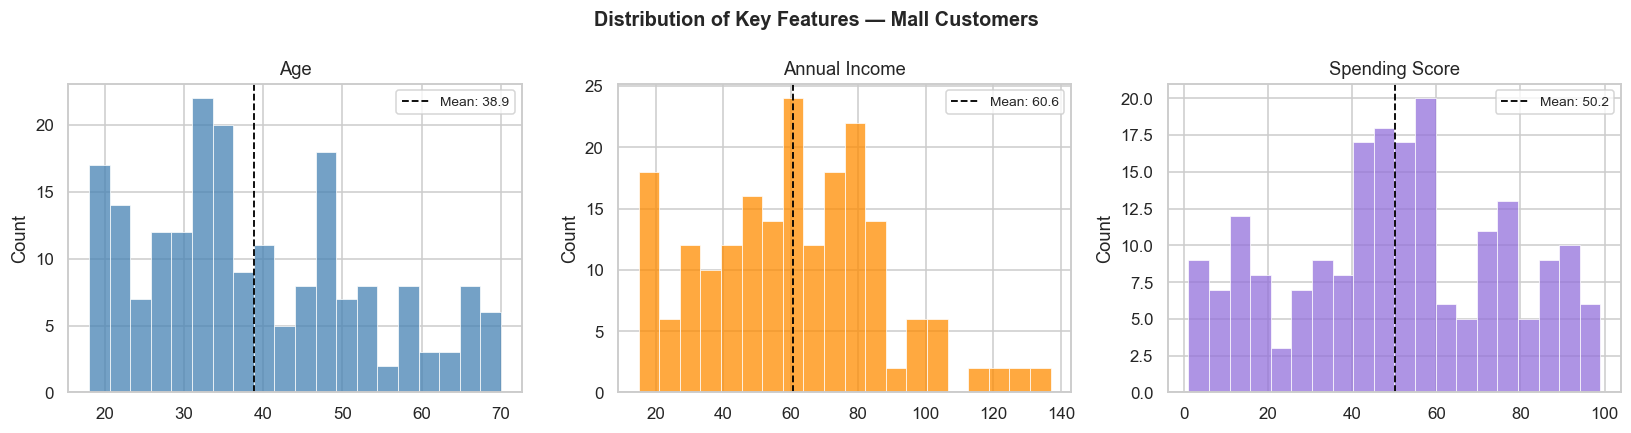

In [15]:
# ── Cell 3b: Distribution Plots ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Distribution of Key Features — Mall Customers', fontsize=13, fontweight='bold')

cols = [('Age','steelblue'), ('Annual_Income','darkorange'), ('Spending_Score','mediumpurple')]
for ax, (col, color) in zip(axes, cols):
    ax.hist(df[col], bins=20, color=color, alpha=0.75, edgecolor='white', linewidth=0.6)
    ax.axvline(df[col].mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'Mean: {df[col].mean():.1f}')
    ax.set_title(col.replace('_',' '))
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

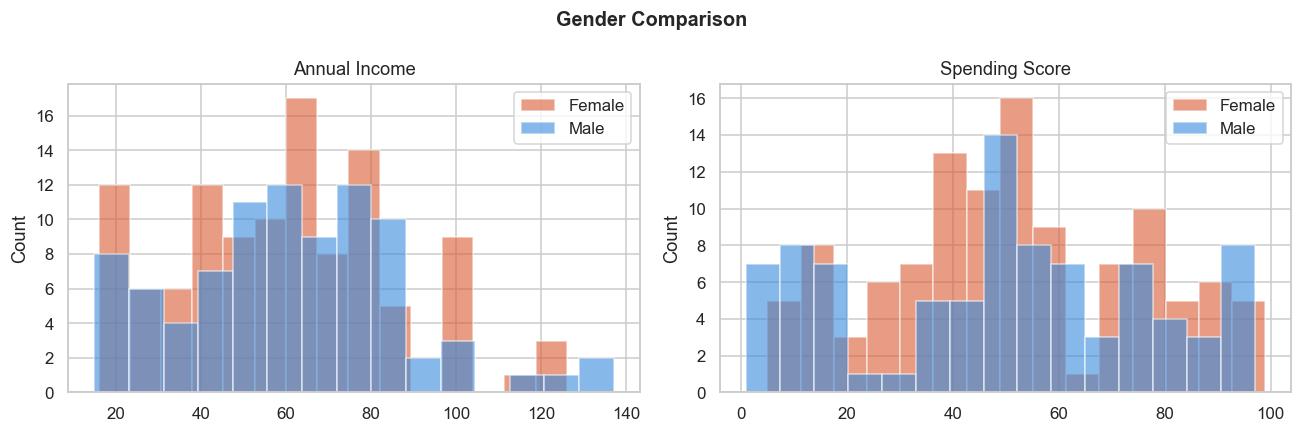

In [16]:
# ── Cell 3c: Gender vs Income & Spending ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Gender Comparison', fontsize=13, fontweight='bold')

gender_colors = {'Male':'#378ADD', 'Female':'#D85A30'}

for ax, col in zip(axes, ['Annual_Income', 'Spending_Score']):
    for gender, grp in df.groupby('Genre'):
        ax.hist(grp[col], bins=15, alpha=0.6, label=gender,
                color=gender_colors[gender], edgecolor='white')
    ax.set_title(col.replace('_',' '))
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.show()

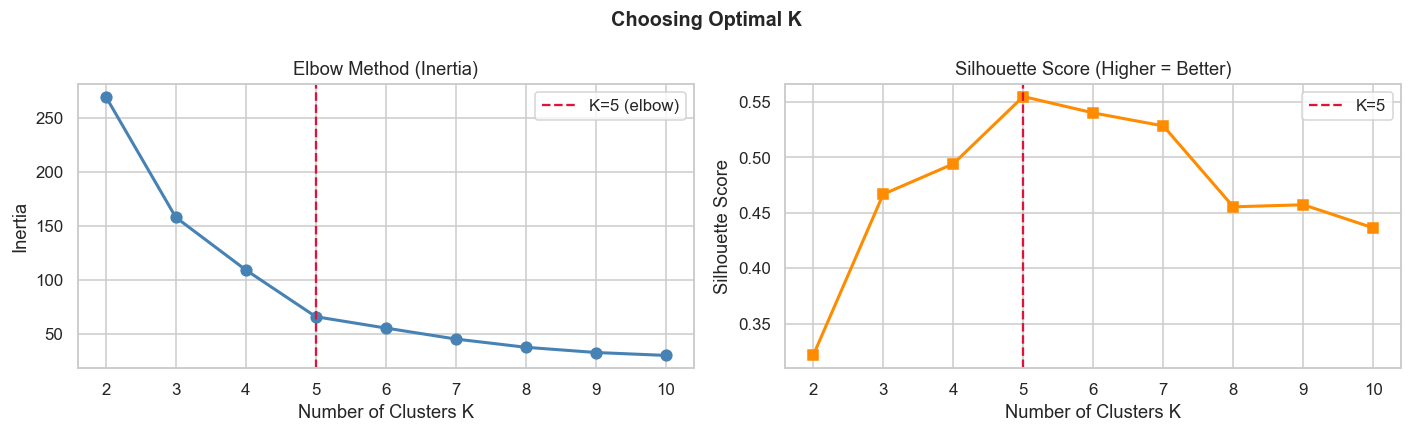


Silhouette Scores:
  K=2  →  0.3213
  K=3  →  0.4666
  K=4  →  0.4939
  K=5  →  0.5547 ◀ Best
  K=6  →  0.5399
  K=7  →  0.5281
  K=8  →  0.4552
  K=9  →  0.4571
  K=10  →  0.4362


In [17]:
# ── Cell 4: Optimal K ─────────────────────────────────────────
# Use Income + Spending Score (classic mall segmentation)
X = df[['Annual_Income', 'Spending_Score']].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia_list    = []
silhouette_list = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=15, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertia_list.append(km.inertia_)
    silhouette_list.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Choosing Optimal K', fontsize=13, fontweight='bold')

ax1.plot(K_range, inertia_list, 'o-', color='steelblue', linewidth=2, markersize=7)
ax1.axvline(x=5, color='crimson', linestyle='--', linewidth=1.5, label='K=5 (elbow)')
ax1.set_title('Elbow Method (Inertia)')
ax1.set_xlabel('Number of Clusters K')
ax1.set_ylabel('Inertia')
ax1.legend()

ax2.plot(K_range, silhouette_list, 's-', color='darkorange', linewidth=2, markersize=7)
ax2.axvline(x=5, color='crimson', linestyle='--', linewidth=1.5, label='K=5')
ax2.set_title('Silhouette Score (Higher = Better)')
ax2.set_xlabel('Number of Clusters K')
ax2.set_ylabel('Silhouette Score')
ax2.legend()

plt.tight_layout()
plt.show()

print('\nSilhouette Scores:')
for k, s in zip(K_range, silhouette_list):
    marker = ' ◀ Best' if s == max(silhouette_list) else ''
    print(f'  K={k}  →  {s:.4f}{marker}')

In [18]:
# ── Cell 5: K-Means Clustering ────────────────────────────────
K = 5
kmeans = KMeans(n_clusters=K, init='k-means++', n_init=15, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Segment profiles
profile = df.groupby('Cluster').agg(
    Count          = ('CustomerID', 'count'),
    Avg_Age        = ('Age', 'mean'),
    Avg_Income     = ('Annual_Income', 'mean'),
    Avg_Spending   = ('Spending_Score', 'mean')
).round(1)

print('=== Cluster Profiles ===')
print(profile)

# Auto-label based on income + spending
def label_cluster(row):
    inc = row['Avg_Income']
    spd = row['Avg_Spending']
    if inc >= 70 and spd >= 65:
        return 'High Income High Spenders'
    elif inc >= 70 and spd <= 40:
        return 'High Income Low Spenders'
    elif inc <= 45 and spd >= 60:
        return 'Low Income High Spenders'
    elif inc <= 45 and spd <= 40:
        return 'Low Income Low Spenders'
    else:
        return 'Average Customers'

profile['Segment'] = profile.apply(label_cluster, axis=1)
cluster_to_seg = profile['Segment'].to_dict()
df['Segment'] = df['Cluster'].map(cluster_to_seg)

print('\n=== Segment Labels ===')
print(profile[['Count','Avg_Income','Avg_Spending','Segment']])

=== Cluster Profiles ===
         Count  Avg_Age  Avg_Income  Avg_Spending
Cluster                                          
0           81     42.7        55.3          49.5
1           39     32.7        86.5          82.1
2           22     25.3        25.7          79.4
3           35     41.1        88.2          17.1
4           23     45.2        26.3          20.9

=== Segment Labels ===
         Count  Avg_Income  Avg_Spending                    Segment
Cluster                                                            
0           81        55.3          49.5          Average Customers
1           39        86.5          82.1  High Income High Spenders
2           22        25.7          79.4   Low Income High Spenders
3           35        88.2          17.1   High Income Low Spenders
4           23        26.3          20.9    Low Income Low Spenders


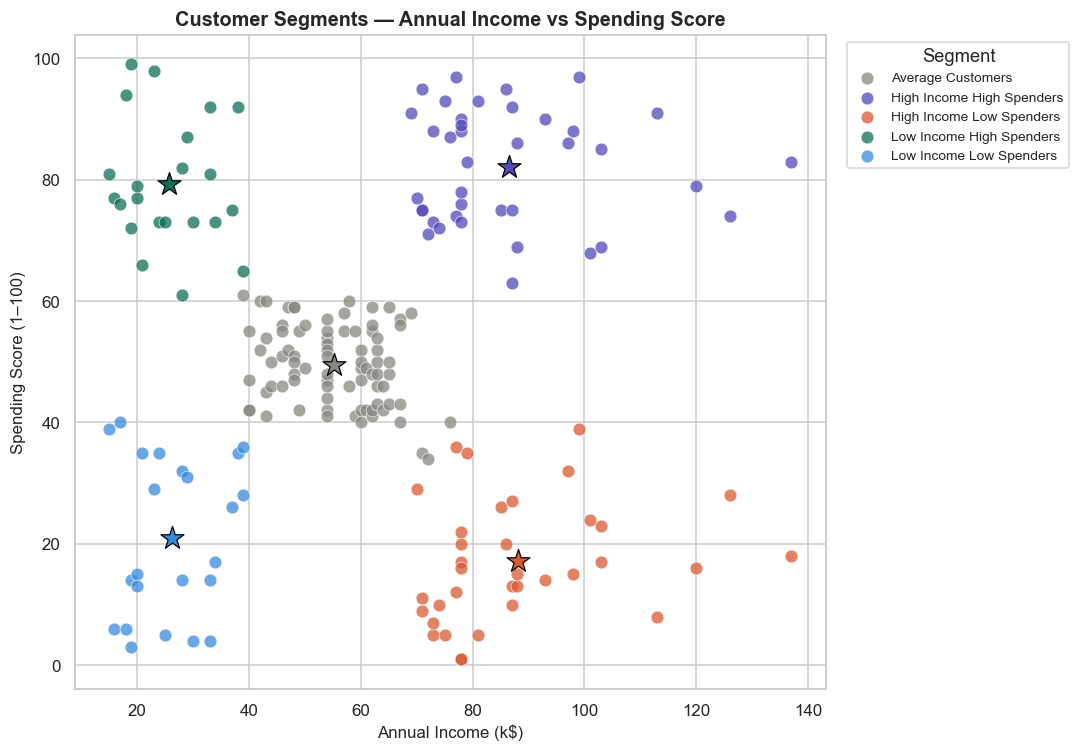

In [19]:
# ── Cell 6: Income vs Spending Scatter ────────────────────────
seg_colors = {
    'High Income High Spenders' : '#534AB7',
    'High Income Low Spenders'  : '#D85A30',
    'Low Income High Spenders'  : '#0F6E56',
    'Low Income Low Spenders'   : '#378ADD',
    'Average Customers'         : '#888780'
}

fig, ax = plt.subplots(figsize=(10, 7))

for seg, grp in df.groupby('Segment'):
    ax.scatter(grp['Annual_Income'], grp['Spending_Score'],
               c=seg_colors.get(seg, 'gray'), label=seg,
               alpha=0.75, s=70, edgecolors='white', linewidths=0.5)

# Plot centroids (inverse-transform from scaled space)
centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)
for i, (cx, cy) in enumerate(centroids_orig):
    seg_name = cluster_to_seg[i]
    ax.scatter(cx, cy, c=seg_colors.get(seg_name,'gray'),
               s=250, marker='*', edgecolors='black', linewidths=0.8, zorder=5)

ax.set_title('Customer Segments — Annual Income vs Spending Score', fontsize=13, fontweight='bold')
ax.set_xlabel('Annual Income (k$)', fontsize=11)
ax.set_ylabel('Spending Score (1–100)', fontsize=11)
ax.legend(title='Segment', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

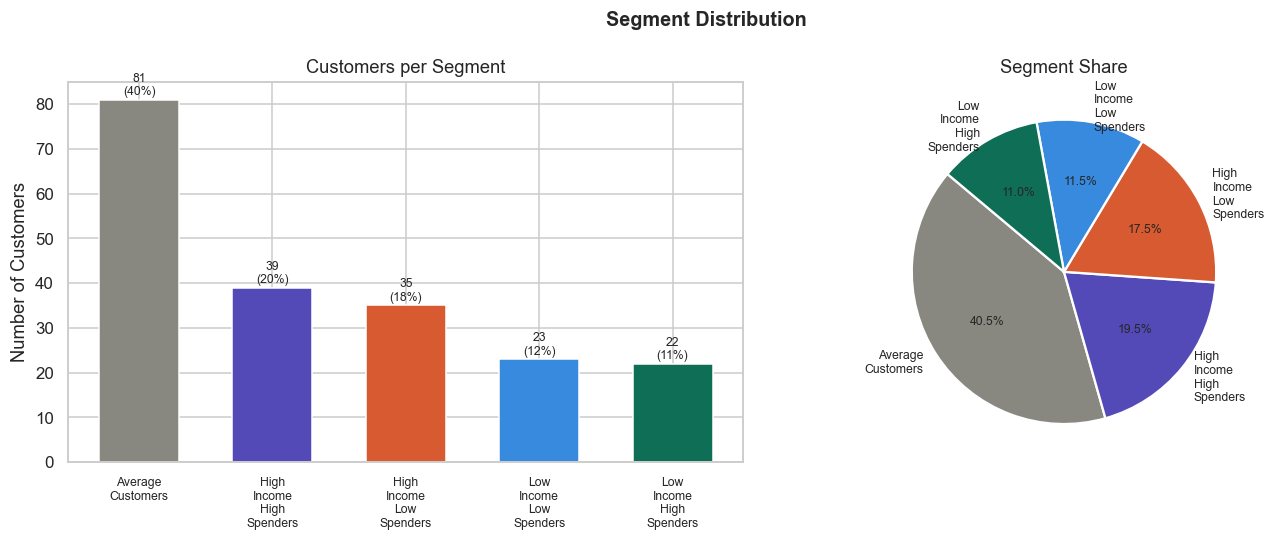

In [23]:
# ── Cell 7: Segment Distribution ─────────────────────────────
seg_order = list(seg_colors.keys())
counts = df['Segment'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Segment Distribution', fontsize=13, fontweight='bold')

# Bar
bars = axes[0].bar(range(len(counts)), counts.values,
                   color=[seg_colors.get(s, 'gray') for s in counts.index],
                   edgecolor='white', width=0.6)

axes[0].set_xticks(range(len(counts)))
axes[0].set_xticklabels([s.replace(' ', '\n') for s in counts.index], fontsize=8)

for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val}\n({val/200*100:.0f}%)', ha='center', fontsize=8)

axes[0].set_ylabel('Number of Customers')
axes[0].set_title('Customers per Segment')

# Pie
axes[1].pie(counts.values,
            labels=[s.replace(' ', '\n') for s in counts.index],
            colors=[seg_colors.get(s, 'gray') for s in counts.index],
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
            textprops={'fontsize': 8})
axes[1].set_title('Segment Share')

plt.tight_layout()
plt.show()

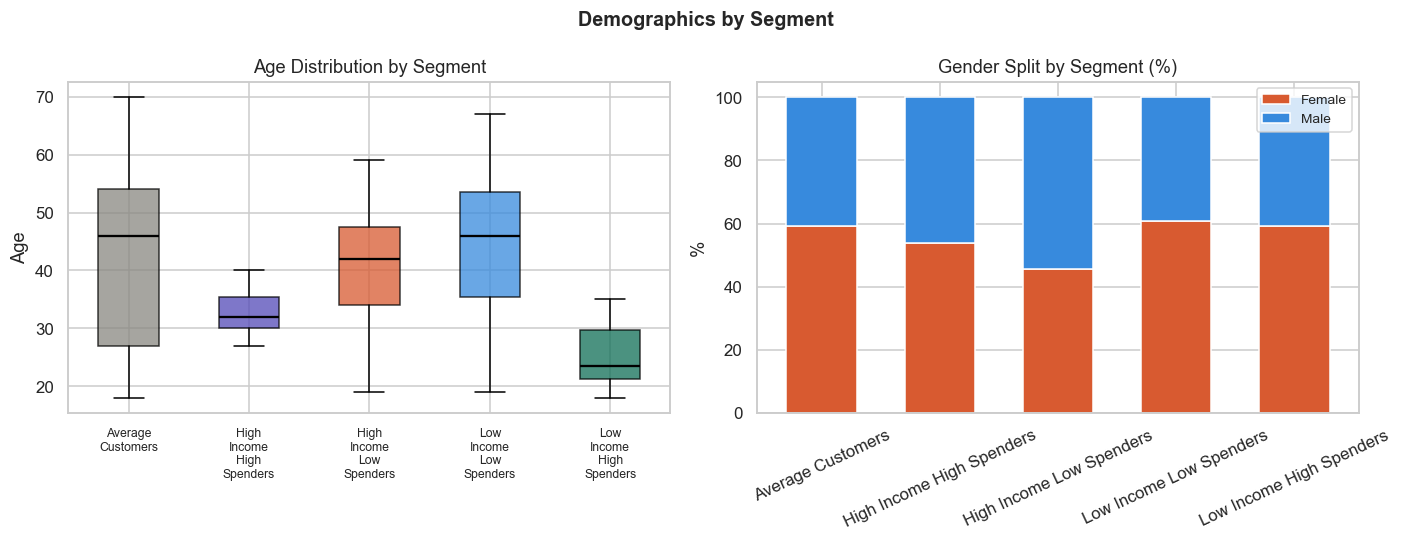

In [30]:
# ── Cell 7b: Age & Gender by Segment ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Demographics by Segment', fontsize=13, fontweight='bold')

# Age boxplot
seg_list = [df[df['Segment']==s]['Age'].values for s in counts.index]
bp = axes[0].boxplot(seg_list, patch_artist=True, widths=0.5,
                     medianprops={'color':'black','linewidth':1.5})
for patch, seg in zip(bp['boxes'], counts.index):
    patch.set_facecolor(seg_colors.get(seg, 'gray'))
    patch.set_alpha(0.75)

axes[0].set_xticks(range(1, len(counts)+1))
axes[0].set_xticklabels([s.replace(' ', '\n') for s in counts.index], fontsize=8)
axes[0].set_title('Age Distribution by Segment')
axes[0].set_ylabel('Age')

# Gender stacked bar
gender_seg = df.groupby(['Segment','Genre']).size().unstack(fill_value=0)
gender_pct = gender_seg.div(gender_seg.sum(axis=1), axis=0) * 100
gender_pct.reindex(counts.index).plot(
    kind='bar', ax=axes[1], stacked=True,
    color=['#D85A30','#378ADD'], edgecolor='white', width=0.6)
axes[1].set_title('Gender Split by Segment (%)')
axes[1].set_xlabel('')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=25)
axes[1].legend(['Female','Male'], fontsize=9)

plt.tight_layout()
plt.show()

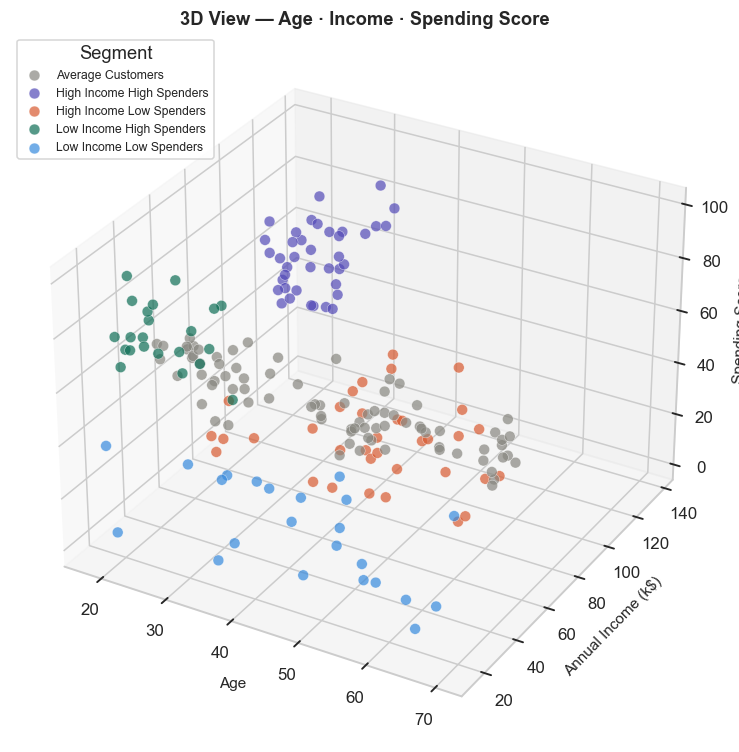

In [25]:
# ── Cell 8: 3D Visualization ──────────────────────────────────
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection='3d')

for seg, grp in df.groupby('Segment'):
    ax.scatter(grp['Age'], grp['Annual_Income'], grp['Spending_Score'],
               c=seg_colors.get(seg,'gray'), label=seg,
               alpha=0.7, s=50, edgecolors='white', linewidths=0.3)

ax.set_xlabel('Age', fontsize=10)
ax.set_ylabel('Annual Income (k$)', fontsize=10)
ax.set_zlabel('Spending Score', fontsize=10)
ax.set_title('3D View — Age · Income · Spending Score', fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=8, title='Segment')
plt.tight_layout()
plt.show()

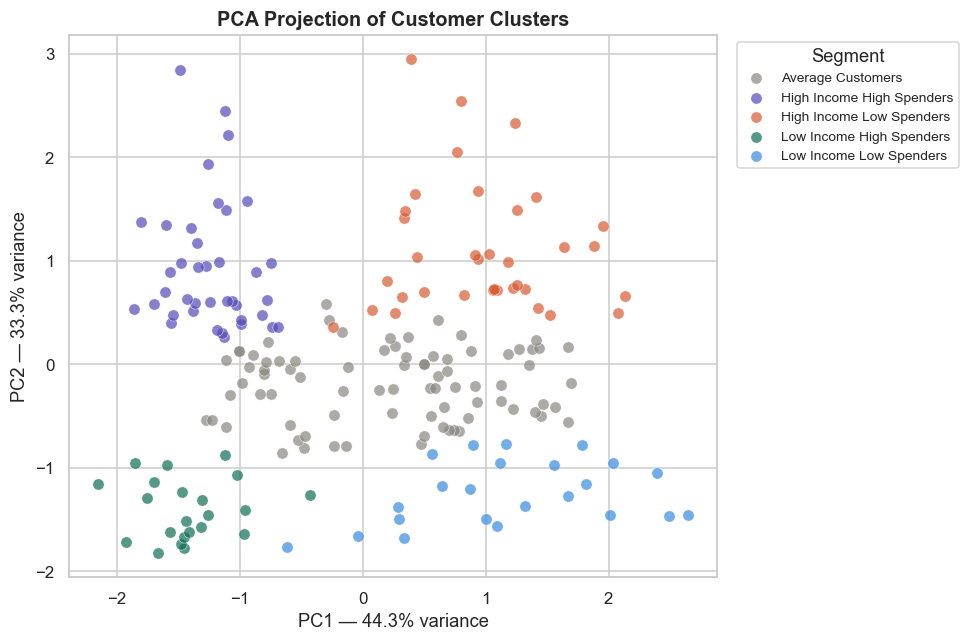

Total variance explained: 77.6%


In [26]:
# ── Cell 9: PCA Plot ──────────────────────────────────────────
# Use all numeric features for PCA
X_full = df[['Age','Annual_Income','Spending_Score']].values
X_full_scaled = StandardScaler().fit_transform(X_full)

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_full_scaled)
df['PCA1'] = coords[:,0]
df['PCA2'] = coords[:,1]

plt.figure(figsize=(9, 6))
for seg, grp in df.groupby('Segment'):
    plt.scatter(grp['PCA1'], grp['PCA2'],
                c=seg_colors.get(seg,'gray'), label=seg,
                alpha=0.7, s=55, edgecolors='white', linewidths=0.4)

plt.title('PCA Projection of Customer Clusters', fontsize=13, fontweight='bold')
plt.xlabel(f'PC1 — {pca.explained_variance_ratio_[0]*100:.1f}% variance')
plt.ylabel(f'PC2 — {pca.explained_variance_ratio_[1]*100:.1f}% variance')
plt.legend(title='Segment', fontsize=9, bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()
print(f'Total variance explained: {sum(pca.explained_variance_ratio_)*100:.1f}%')

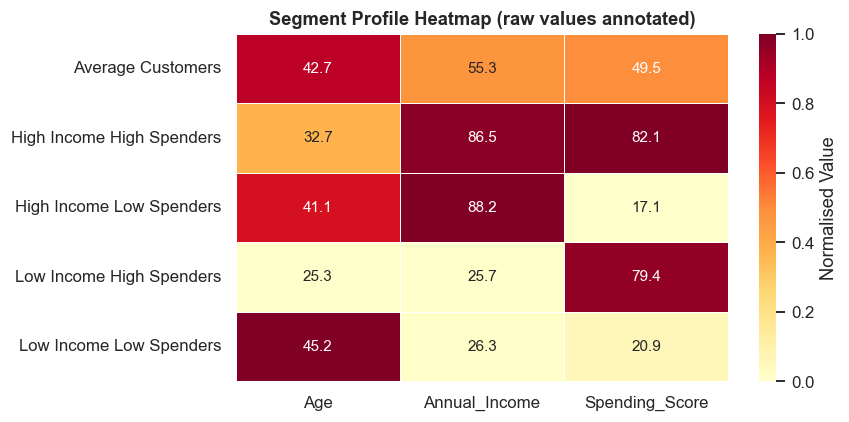

In [27]:
# ── Cell 10: Profile Heatmap ──────────────────────────────────
heat_df = df.groupby('Segment')[['Age','Annual_Income','Spending_Score']].mean().round(1)
heat_norm = (heat_df - heat_df.min()) / (heat_df.max() - heat_df.min())

plt.figure(figsize=(8, 4))
sns.heatmap(heat_norm, annot=heat_df, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label':'Normalised Value'},
            annot_kws={'fontsize':10})
plt.title('Segment Profile Heatmap (raw values annotated)', fontsize=12, fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [28]:
# ── Cell 11: Recommendations ──────────────────────────────────
strategies = {
    'High Income High Spenders': {
        'emoji':'👑', 'priority':'🔴 Top Priority',
        'desc':'Wealthy and love to spend — your most valuable segment.',
        'actions':[
            'Offer VIP memberships & exclusive loyalty rewards',
            'Showcase premium & luxury product lines',
            'Personal shopper or concierge shopping experience'
        ]
    },
    'High Income Low Spenders': {
        'emoji':'💼', 'priority':'🟠 High Potential',
        'desc':'Earn well but spend conservatively — untapped revenue.',
        'actions':[
            'Send targeted campaigns highlighting value & quality',
            'Bundle deals & savings-focused offers',
            'Build trust through reviews, quality guarantees'
        ]
    },
    'Low Income High Spenders': {
        'emoji':'🛒', 'priority':'🟡 Engage Carefully',
        'desc':'Enthusiastic shoppers despite lower income — watch for churn.',
        'actions':[
            'Offer instalment / buy-now-pay-later options',
            'Flash sales & limited-time discounts',
            'Loyalty points that accumulate quickly'
        ]
    },
    'Low Income Low Spenders': {
        'emoji':'🌱', 'priority':'🟢 Nurture',
        'desc':'Budget-conscious customers with low engagement.',
        'actions':[
            'Discount coupons and everyday value promotions',
            'Entry-level product recommendations',
            'Re-engagement email sequences'
        ]
    },
    'Average Customers': {
        'emoji':'⚖️', 'priority':'🔵 Maintain',
        'desc':'Middle-ground customers — stable but growth opportunity exists.',
        'actions':[
            'Cross-sell complementary products',
            'Seasonal promotions & mid-tier bundles',
            'Survey to understand preferences better'
        ]
    }
}

print('=' * 65)
print('     MALL CUSTOMER SEGMENTATION — MARKETING PLAYBOOK')
print('=' * 65)
for seg, info in strategies.items():
    cnt  = df[df['Segment']==seg].shape[0]
    pct  = cnt / 200 * 100
    avg_inc = df[df['Segment']==seg]['Annual_Income'].mean()
    avg_spd = df[df['Segment']==seg]['Spending_Score'].mean()
    print(f"\n{info['emoji']}  {seg.upper()}")
    print(f"   {info['priority']}  |  {cnt} customers ({pct:.0f}%)  |  Avg Income: ${avg_inc:.0f}k  |  Avg Spending: {avg_spd:.0f}")
    print(f"   {info['desc']}")
    for i, a in enumerate(info['actions'],1):
        print(f"   {i}. {a}")
print('\n' + '=' * 65)

     MALL CUSTOMER SEGMENTATION — MARKETING PLAYBOOK

👑  HIGH INCOME HIGH SPENDERS
   🔴 Top Priority  |  39 customers (20%)  |  Avg Income: $87k  |  Avg Spending: 82
   Wealthy and love to spend — your most valuable segment.
   1. Offer VIP memberships & exclusive loyalty rewards
   2. Showcase premium & luxury product lines
   3. Personal shopper or concierge shopping experience

💼  HIGH INCOME LOW SPENDERS
   🟠 High Potential  |  35 customers (18%)  |  Avg Income: $88k  |  Avg Spending: 17
   Earn well but spend conservatively — untapped revenue.
   1. Send targeted campaigns highlighting value & quality
   2. Bundle deals & savings-focused offers
   3. Build trust through reviews, quality guarantees

🛒  LOW INCOME HIGH SPENDERS
   🟡 Engage Carefully  |  22 customers (11%)  |  Avg Income: $26k  |  Avg Spending: 79
   Enthusiastic shoppers despite lower income — watch for churn.
   1. Offer instalment / buy-now-pay-later options
   2. Flash sales & limited-time discounts
   3. Loyalty

In [29]:
# ── Cell 12: Export ───────────────────────────────────────────
out = df[['CustomerID','Genre','Age','Annual_Income','Spending_Score','Cluster','Segment']]
out.to_csv('Mall_Customers_Segmented.csv', index=False)

print('✅ Saved: Mall_Customers_Segmented.csv')
print()
print('=== Final Segment Summary ===')
summary = df.groupby('Segment').agg(
    Customers     = ('CustomerID','count'),
    Avg_Age       = ('Age','mean'),
    Avg_Income_k  = ('Annual_Income','mean'),
    Avg_Spending  = ('Spending_Score','mean'),
    Female_Pct    = ('Genre', lambda x: (x=='Female').mean()*100)
).round(1)
summary['Share_%'] = (summary['Customers']/200*100).round(1)
print(summary)
out.head(10)

✅ Saved: Mall_Customers_Segmented.csv

=== Final Segment Summary ===
                           Customers  Avg_Age  Avg_Income_k  Avg_Spending  \
Segment                                                                     
Average Customers                 81     42.7          55.3          49.5   
High Income High Spenders         39     32.7          86.5          82.1   
High Income Low Spenders          35     41.1          88.2          17.1   
Low Income High Spenders          22     25.3          25.7          79.4   
Low Income Low Spenders           23     45.2          26.3          20.9   

                           Female_Pct  Share_%  
Segment                                         
Average Customers                59.3     40.5  
High Income High Spenders        53.8     19.5  
High Income Low Spenders         45.7     17.5  
Low Income High Spenders         59.1     11.0  
Low Income Low Spenders          60.9     11.5  


,CustomerID,Genre,Age,Annual_Income,Spending_Score,Cluster,Segment
0,1,Male,19,15,39,4,Low Income Low Spenders
1,2,Male,21,15,81,2,Low Income High Spenders
2,3,Female,20,16,6,4,Low Income Low Spenders
3,4,Female,23,16,77,2,Low Income High Spenders
4,5,Female,31,17,40,4,Low Income Low Spenders
5,6,Female,22,17,76,2,Low Income High Spenders
6,7,Female,35,18,6,4,Low Income Low Spenders
7,8,Female,23,18,94,2,Low Income High Spenders
8,9,Male,64,19,3,4,Low Income Low Spenders
9,10,Female,30,19,72,2,Low Income High Spenders
